# **Task 3: Customer Segmentation using K-Means Clustering**

## Problem Objective

A shopping mall (retail store) has many customers, and **every customer is different**. Some customers spend a lot, some spend very little, some earn a lot, some earn less.

If the mall treats all customers in the same way, it wastes money on advertising. It is better to **divide customers into groups of similar people** and then plan offers for each group. This is called **Customer Segmentation**.

In this task, we will:

- Load and understand the customer dataset.
- Check the data for missing values and duplicates.
- Explore the data with simple charts.
- Scale (normalize) the numbers so that they are fair to each other.
- Use the **Elbow Method** to find the best number of groups (clusters).
- Use the **K-Means algorithm** to make the groups.
- **Visualize** the groups and explain each group in simple words.

## Introduction to the Dataset and K-Means

### The Dataset
The **Mall Customers dataset** has information about **200 customers** of a shopping mall:

| Column | Meaning |
|---|---|
| `CustomerID` | A unique number for each customer (just an ID) |
| `Gender` | Male or Female |
| `Age` | Age of the customer |
| `Annual Income (k$)` | Yearly income in thousand dollars |
| `Spending Score (1-100)` | A score given by the mall. **High score = customer spends more**, low score = customer spends less |

> **Note:** The task says "transaction dataset". In this dataset, the **Spending Score** is made from the customer's shopping behaviour (what and how much they buy), so it works as a short summary of their transactions.

### What is Clustering?
**Clustering** means putting similar things in the same group. Nobody tells the computer the group names in advance. The computer finds the groups by itself. This is called **unsupervised learning** (there is no target column like `y` in Task 2).

### What is K-Means?
**K-Means** is a clustering method. It works in simple steps:

1. We choose a number **K** (how many groups we want).
2. The computer places K points on the chart. These points are called **centroids** (the "center" of a group).
3. Every customer joins the **nearest** centroid.
4. Each centroid moves to the middle of its customers.
5. Steps 3 and 4 repeat until nothing changes.

### What is the Elbow Method?
We do not know the best K in advance. So we try K = 1, 2, 3 ... 10 and measure **inertia**.

- **Inertia** = how far customers are from their own group center. **Smaller inertia = tighter, better groups.**
- When we draw inertia against K, the line goes down like an arm.
- The point where the line **bends like an elbow** is the best K. After that point, adding more groups gives only a small improvement.

## Project Summary

In this project we used **K-Means clustering** to segment **200 mall customers**.

- The data was clean: **no missing values and no duplicate rows**.
- We used **Annual Income** and **Spending Score** to make the groups, because these two features describe shopping value best and can be shown on a 2D chart.
- Both features were **scaled** with `StandardScaler`.
- The **Elbow Method** showed the bend at **K = 5**. The **Silhouette Score** (a second check) was also highest at **K = 5**.
- The five customer groups found were:
  1. **Average Customers** (middle income, middle spending)
  2. **Big Spenders** (high income, high spending) - the best group to target
  3. **Careful Rich** (high income, low spending)
  4. **Fun Spenders** (low income, high spending)
  5. **Budget Savers** (low income, low spending)
- For each group, we also gave a simple business idea.

# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

## Observation (Simple Words)

We have brought in all the tools we need.

- **Pandas** and **NumPy** - to read and handle the data.
- **Matplotlib** and **Seaborn** - to draw charts.
- **StandardScaler** - to scale the numbers.
- **KMeans** - the algorithm that makes the groups.
- **silhouette_score** - a score that tells how good the groups are.

# Step 2: Load the Dataset

> In Google Colab, first upload `Mall_Customers.csv` using the folder icon on the left side.

In [2]:
df = pd.read_csv("Mall_Customers.csv")

# Display the first 5 rows

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Observation (Simple Words)

The data is loaded. Each row is **one customer**.

- The first columns are `CustomerID`, `Gender` and `Age`.
- Then we have `Annual Income (k$)` - how much the customer earns in a year.
- And `Spending Score (1-100)` - how much the customer spends in the mall.
- Example: Customer 1 earns 15k and has a spending score of 39. Customer 4 also earns only 16k but has a score of 77, which means **similar income, but very different spending**. This is exactly why we need groups.

# Step 3: Understand the Dataset

# Check the number of rows and columns

In [4]:
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

Rows    : 200
Columns : 5


# Check column names

In [5]:
df.columns.tolist()

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Check data types

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


## Observation (Simple Words)

- The dataset has **200 rows** (200 customers) and **5 columns**.
- `CustomerID`, `Age`, `Annual Income (k$)` and `Spending Score (1-100)` are **numbers**.
- `Gender` is **text** (Male / Female).
- Every column shows **200 non-null** values, which means nothing is empty.
- The dataset is small, so it is easy to understand and to draw.

# Step 4: Check Missing Values and Duplicates

In [7]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values in each column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


## Observation (Simple Words)

- There are **0 missing values** in every column.
- There are **0 duplicate rows**.
- So the data is **clean**, and we do not need to fill or delete anything.
- (In Task 2 we had to deal with `unknown` values. Here we do not have that problem.)

# Step 5: Statistical Summary

In [8]:
df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].describe().round(2)

,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00
mean,38.85,60.56,50.20
std,13.97,26.26,25.82
min,18.00,15.00,1.00
25%,28.75,41.50,34.75
50%,36.00,61.50,50.00
75%,49.00,78.00,73.00
max,70.00,137.00,99.00


## Observation (Simple Words)

This table gives a quick picture of the customers.

- **Age:** customers are between **18 and 70** years old. The average age is about **39**.
- **Annual Income:** it goes from **15k to 137k**. The average is about **61k**.
- **Spending Score:** it goes from **1 to 99**. The average is about **50**.
- The three columns have **different ranges** (Age up to 70, Income up to 137, Score up to 99). Because of this, we will **scale** the data before using K-Means (Step 8).

# Step 6: Explore the Data with Charts

### 6.1 How many Male and Female customers?

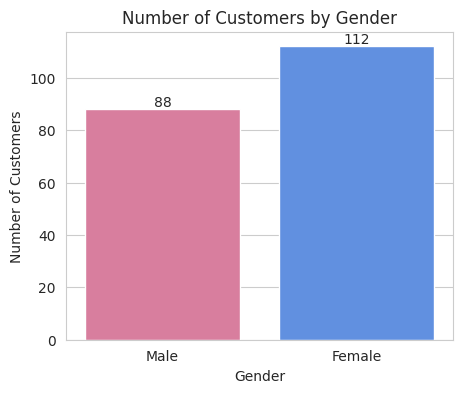

In [9]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df, x="Gender", palette=["#e76f9a", "#4c8bf5"])
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Number of Customers by Gender")
plt.ylabel("Number of Customers")
plt.show()

## Observation (Simple Words)

- There are **112 Female** and **88 Male** customers.
- So about **56% are female** and **44% are male**.
- The numbers are close, so the data is fairly balanced.

### 6.2 How are Age, Income and Spending Score spread?

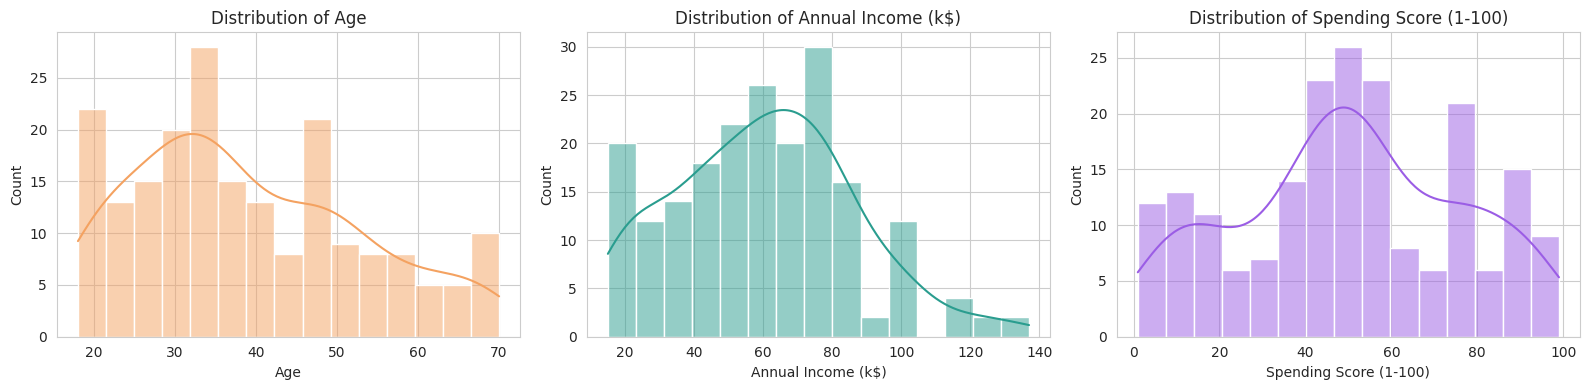

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
colors = ["#f4a261", "#2a9d8f", "#9b5de5"]

for ax, col, color in zip(axes, cols, colors):
    sns.histplot(df[col], bins=15, kde=True, color=color, ax=ax)
    ax.set_title("Distribution of " + col)

plt.tight_layout()
plt.show()

## Observation (Simple Words)

A histogram shows **how many customers fall in each range**. Taller bar = more customers.

- **Age:** most customers are in their **20s to 40s**. Fewer customers are above 60.
- **Annual Income:** most customers earn between **40k and 80k**. Only a few customers earn more than 100k.
- **Spending Score:** the bars are spread widely, with many customers near the **middle (around 50)**. There are customers at both low and high scores.
- Nothing looks wrong or strange, so we can move ahead.

### 6.3 Are the features related to each other? (Correlation)

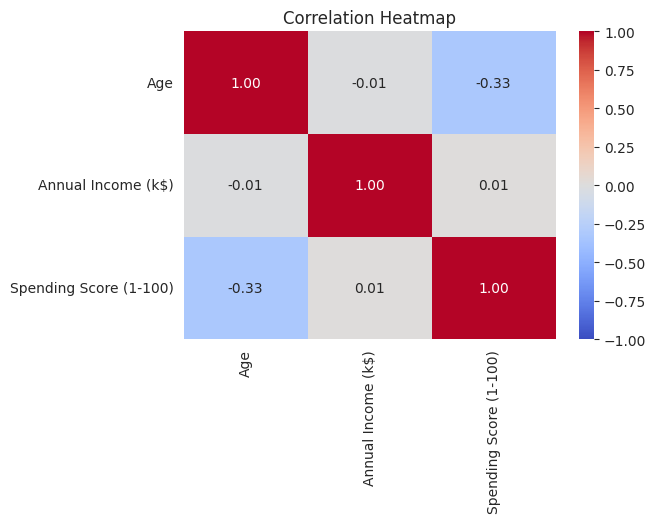

In [11]:
plt.figure(figsize=(6, 4))
corr = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Observation (Simple Words)

Correlation tells **if two things move together**. A value near **0** means no relation. A value near **1** or **-1** means a strong relation.

- **Income vs Spending Score = 0.01** -> almost **no relation**. A rich customer does **not** always spend more.
- **Age vs Income = -0.01** -> no relation.
- **Age vs Spending Score = -0.33** -> a **small negative** relation. Younger customers tend to have **slightly higher** spending scores.
- Because income and spending do not follow a simple straight line, **clustering is a good tool here**. It can find groups that a simple rule cannot.

### 6.4 Income vs Spending Score (before clustering)

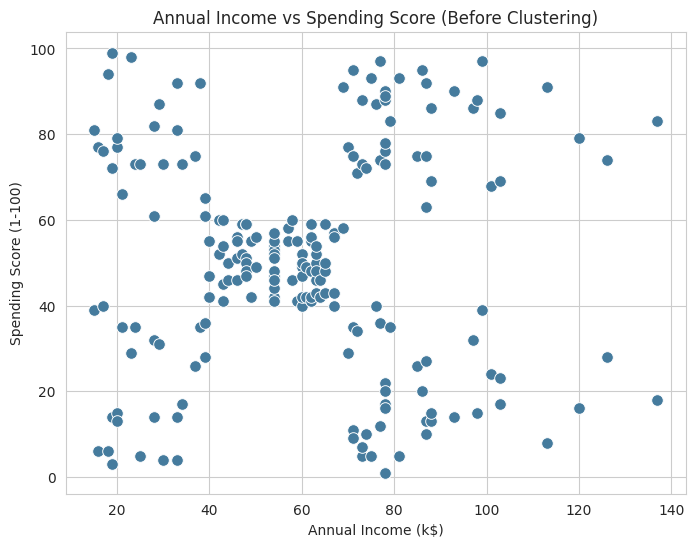

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                color="#457b9d", s=70, edgecolor="white")
plt.title("Annual Income vs Spending Score (Before Clustering)")
plt.show()

## Observation (Simple Words)

Each dot is **one customer**. We have not made any groups yet, but we can already see some patterns with our eyes:

- A big crowd of dots sits in the **middle** of the chart.
- There is a group at the **top right** (high income **and** high spending).
- There is a group at the **bottom right** (high income but **low** spending).
- There is a group at the **top left** (low income but **high** spending).
- There is a group at the **bottom left** (low income **and** low spending).
- So it looks like there are about **5 natural groups**. Let us check this with the Elbow Method.

# Step 7: Select Features for Clustering

In [13]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Observation (Simple Words)

We use only **two columns** to make the groups:

- **Annual Income (k$)** - how much money the customer earns.
- **Spending Score (1-100)** - how much the customer spends.

**Why not the other columns?**

- `CustomerID` is only a number to identify a customer. It has **no meaning** for grouping.
- `Gender` is text. K-Means works with numbers and measures distance, so text is not suitable without extra encoding.
- `Age` is useful, so we will use it later to **understand** each group (Step 14).
- With two features we can draw a clear **2D chart** that is easy to read.

# Step 8: Scale the Features

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("First 5 rows after scaling:")
display(X_scaled_df.head())

print("\nMean and Standard Deviation after scaling:")
display(X_scaled_df.describe().round(2).loc[["mean", "std"]])

First 5 rows after scaling:


,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980



Mean and Standard Deviation after scaling:


,Annual Income (k$),Spending Score (1-100)
mean,-0.0,-0.0
std,1.0,1.0


## Observation (Simple Words)

**Why do we scale?** K-Means finds groups using **distance**. If one column has bigger numbers (like income up to 137), it can overpower the other column (score up to 99). Scaling puts both columns on the **same level**, so both are treated **fairly**.

- `StandardScaler` changes every column so that the **average becomes 0** and the **spread (standard deviation) becomes 1**.
- The table above confirms it: **mean = 0** and **std = 1** for both columns.
- Now a value like `-1.7` simply means "much lower than average" and `+1.7` means "much higher than average".

# Step 9: Elbow Method - Find the Best Number of Clusters

,K (Number of Clusters),Inertia
0,1,400.0
1,2,269.7
2,3,157.7
3,4,108.9
4,5,65.6
5,6,55.1
6,7,44.9
7,8,37.2
8,9,32.4
9,10,30.0


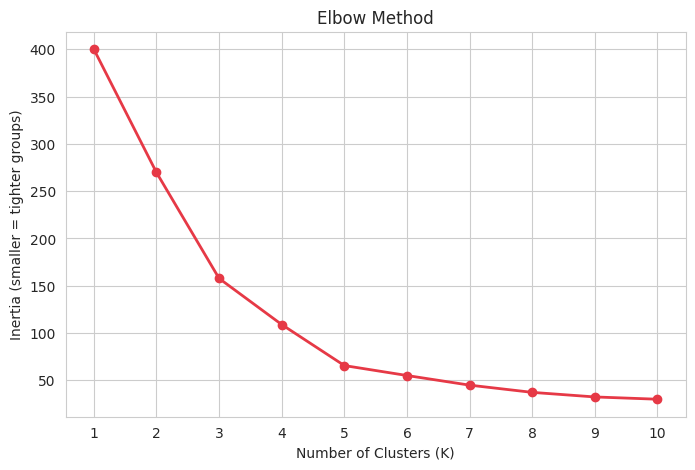

In [15]:
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

elbow_table = pd.DataFrame({"K (Number of Clusters)": list(K_range),
                            "Inertia": np.round(inertia_values, 1)})
display(elbow_table)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker="o", color="#e63946", linewidth=2)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (smaller = tighter groups)")
plt.xticks(K_range)
plt.grid(True)
plt.show()

## Observation (Simple Words)

We tried K from 1 to 10 and measured the inertia (how spread-out the groups are).

- The line **falls very fast** from K = 1 (inertia 400) down to K = 5 (inertia about 66).
- After **K = 5**, the line becomes almost **flat**. From 5 to 6 it drops only about 10 points, and later drops are even smaller.
- The **bend (the "elbow") is at K = 5**.
- Meaning: **5 groups is the best choice**. Fewer than 5 groups mixes different customers together. More than 5 groups gives only a tiny improvement and makes the groups too small and hard to use.

# Step 10: Double-Check with Silhouette Score

,K (Number of Clusters),Silhouette Score
0,2,0.321
1,3,0.467
2,4,0.494
3,5,0.555
4,6,0.540
5,7,0.528
6,8,0.455
7,9,0.457
8,10,0.443


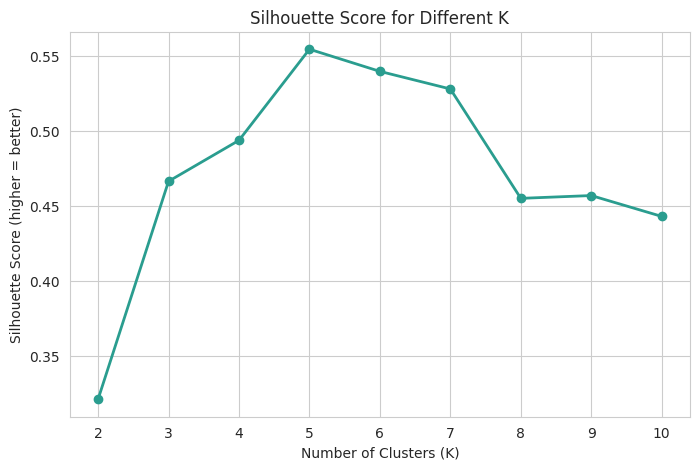

In [16]:
sil_scores = []
K_sil = range(2, 11)

for k in K_sil:
    model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = model.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

sil_table = pd.DataFrame({"K (Number of Clusters)": list(K_sil),
                          "Silhouette Score": np.round(sil_scores, 3)})
display(sil_table)

plt.figure(figsize=(8, 5))
plt.plot(K_sil, sil_scores, marker="o", color="#2a9d8f", linewidth=2)
plt.title("Silhouette Score for Different K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score (higher = better)")
plt.xticks(K_sil)
plt.grid(True)
plt.show()

## Observation (Simple Words)

The **Silhouette Score** tells how **well separated** the groups are. It goes from -1 to 1, and **higher is better**. We use it as a second opinion to confirm the Elbow Method.

- The score is **highest at K = 5 (about 0.555)**.
- It goes **down** after 5 (for example about 0.54 at K = 6 and 0.46 at K = 8).
- So **both methods agree: K = 5 is the best number of clusters.**
- A score above 0.5 means the groups are **clear and well separated**.

# Step 11: Train the Final K-Means Model (K = 5)

In [17]:
kmeans = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Final inertia          :", round(kmeans.inertia_, 1))
print("Final silhouette score :", round(silhouette_score(X_scaled, df["Cluster"]), 3))

df[["CustomerID", "Annual Income (k$)", "Spending Score (1-100)", "Cluster"]].head(10)

Final inertia          : 65.6
Final silhouette score : 0.555


,CustomerID,Annual Income (k$),Spending Score (1-100),Cluster
0,1,15,39,4
1,2,15,81,2
2,3,16,6,4
3,4,16,77,2
4,5,17,40,4
5,6,17,76,2
6,7,18,6,4
7,8,18,94,2
8,9,19,3,4
9,10,19,72,2


## Observation (Simple Words)

- The model has now made **5 groups** and gave each customer a **cluster number from 0 to 4**.
- We saved this number in a new column called `Cluster`.
- The numbers 0 to 4 are **only labels**. They do **not** mean "best" or "worst". We will give each group a proper name in Step 13.
- `n_init=10` means the model tried 10 different starting points and kept the best result. `random_state=42` makes sure we get the **same result** every time we run it.

# Step 12: Visualize the Clusters

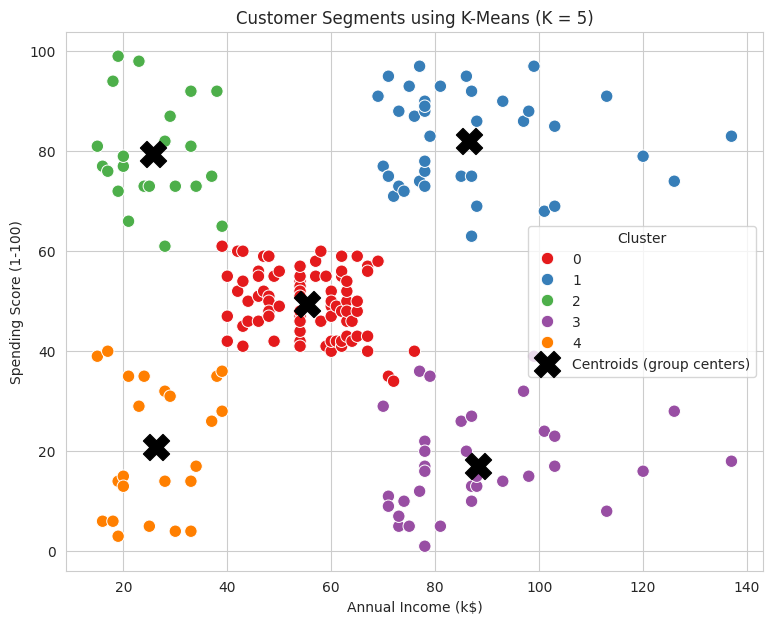

In [18]:
# Centroids are in scaled form, so we convert them back to real values
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                hue="Cluster", palette="Set1", s=80, edgecolor="white")
plt.scatter(centroids[:, 0], centroids[:, 1], s=350, c="black", marker="X",
            label="Centroids (group centers)")
plt.title("Customer Segments using K-Means (K = 5)")
plt.legend(title="Cluster")
plt.show()

## Observation (Simple Words)

Each colour is **one group**. The black **X** is the **center** of that group (the centroid).

- The groups are **clearly separated** from each other, like five islands.
- **Top right:** customers with **high income and high spending**.
- **Bottom right:** customers with **high income but low spending**.
- **Top left:** customers with **low income but high spending**.
- **Bottom left:** customers with **low income and low spending**.
- **Middle:** the largest group, with **average income and average spending**.
- This matches what we guessed from the chart in Step 6.4. K-Means has found the same groups, and now we have exact boundaries.

# Step 13: Understand and Name Each Cluster

In [19]:
# Average values of each cluster (real values, not scaled)
profile = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_Income=("Annual Income (k$)", "mean"),
    Avg_Spending=("Spending Score (1-100)", "mean")
).round(1)

# Give a simple name using income and spending
def give_name(row):
    income, spend = row["Avg_Income"], row["Avg_Spending"]
    if income >= 70 and spend >= 60:
        return "Big Spenders"
    elif income >= 70 and spend < 40:
        return "Careful Rich"
    elif income < 40 and spend >= 60:
        return "Fun Spenders"
    elif income < 40 and spend < 40:
        return "Budget Savers"
    else:
        return "Average Customers"

profile["Segment"] = profile.apply(give_name, axis=1)
profile = profile.sort_values("Avg_Spending", ascending=False)
profile

,Customers,Avg_Age,Avg_Income,Avg_Spending,Segment
Cluster,,,,,
1,39,32.7,86.5,82.1,Big Spenders
2,22,25.3,25.7,79.4,Fun Spenders
0,81,42.7,55.3,49.5,Average Customers
4,23,45.2,26.3,20.9,Budget Savers
3,35,41.1,88.2,17.1,Careful Rich


## Observation (Simple Words)

This table is the **most important result**. It tells us **who is in each group**.

| Segment | Customers | Avg Age | Avg Income | Avg Spending | What it means |
|---|---|---|---|---|---|
| **Big Spenders** | 39 | ~33 | ~87k | ~82 | Earn a lot **and** spend a lot. Best customers. |
| **Fun Spenders** | 22 | ~25 | ~26k | ~79 | Young, earn less, but **love to spend**. |
| **Average Customers** | 81 | ~43 | ~55k | ~50 | The biggest group. Middle in everything. |
| **Budget Savers** | 23 | ~45 | ~26k | ~21 | Earn less and spend less. Older customers. |
| **Careful Rich** | 35 | ~41 | ~88k | ~17 | Earn a lot but **spend very little**. |

- **Average Customers** are the largest group (81 out of 200 = about 40%).
- **Big Spenders** and **Careful Rich** have almost the **same income (~87-88k)**, but their spending is **completely different** (82 vs 17). This shows income alone cannot tell us how much a person spends.

# Step 14: Final Cluster Chart with Names

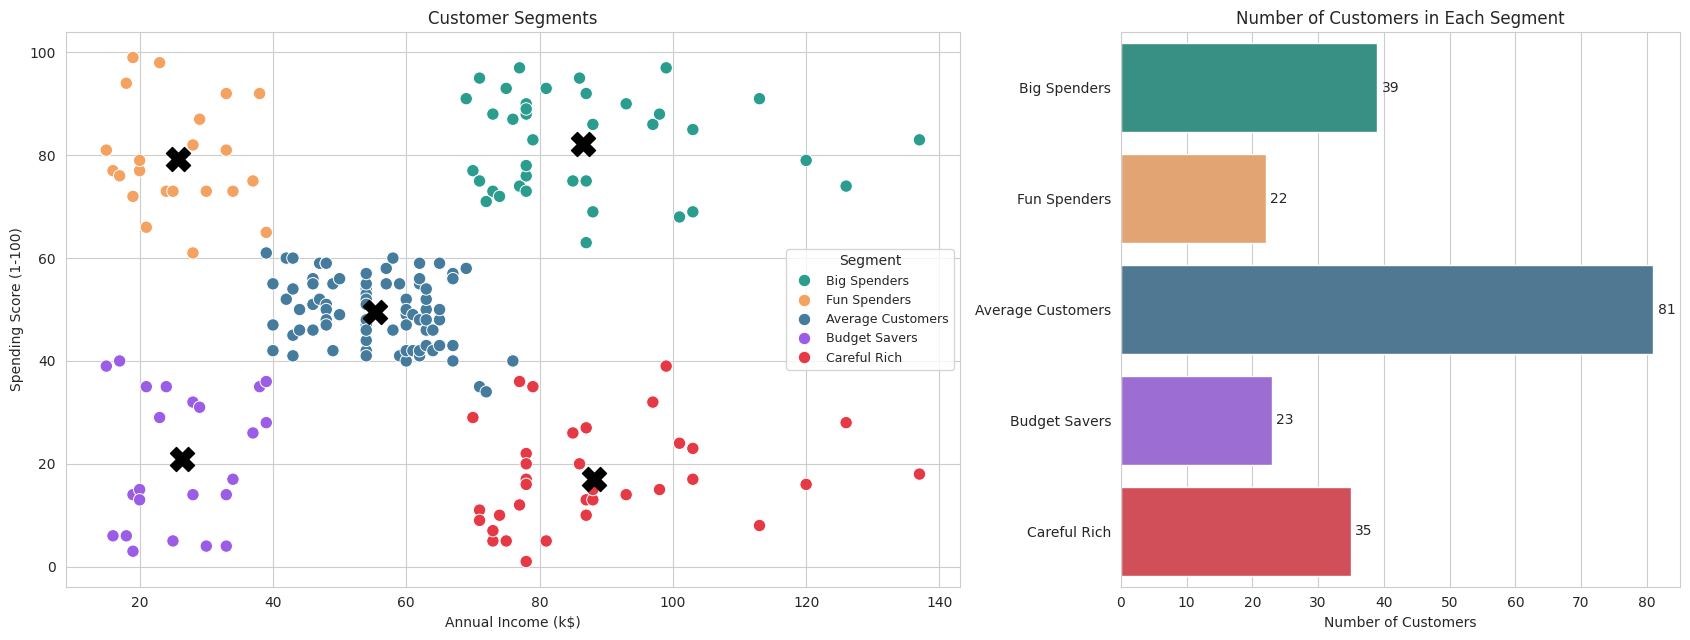

In [20]:
df["Segment"] = df["Cluster"].map(profile["Segment"])

segment_colors = {
    "Big Spenders": "#2a9d8f",
    "Fun Spenders": "#f4a261",
    "Average Customers": "#457b9d",
    "Budget Savers": "#9b5de5",
    "Careful Rich": "#e63946",
}
order = ["Big Spenders", "Fun Spenders", "Average Customers", "Budget Savers", "Careful Rich"]

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), gridspec_kw={"width_ratios": [1.6, 1]})

# Left chart: segments on the scatter plot
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                hue="Segment", hue_order=order, palette=segment_colors,
                s=80, edgecolor="white", ax=axes[0])
axes[0].scatter(centroids[:, 0], centroids[:, 1], s=300, c="black", marker="X")
axes[0].set_title("Customer Segments")
axes[0].legend(title="Segment", fontsize=9)

# Right chart: number of customers in each segment
ax = sns.countplot(data=df, y="Segment", order=order, palette=segment_colors, ax=axes[1])
for bars in ax.containers:
    ax.bar_label(bars, padding=3)
axes[1].set_title("Number of Customers in Each Segment")
axes[1].set_xlabel("Number of Customers")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Observation (Simple Words)

**Left chart:** the same groups as before, now with **easy names** instead of numbers.

- **Big Spenders** (green) are at the **top right**.
- **Fun Spenders** (orange) are at the **top left**.
- **Budget Savers** (purple) are at the **bottom left**.
- **Careful Rich** (red) are at the **bottom right**.
- **Average Customers** (blue) are in the **middle**.

**Right chart:** how big each group is.

- **Average Customers: 81** - the largest group (about 40%).
- **Big Spenders: 39** and **Careful Rich: 35** - medium-sized groups.
- **Budget Savers: 23** and **Fun Spenders: 22** - the smallest groups.
- Together, **Big Spenders + Fun Spenders = 61 customers** (about 30%) have a high spending score.

# Step 15: Compare the Segments

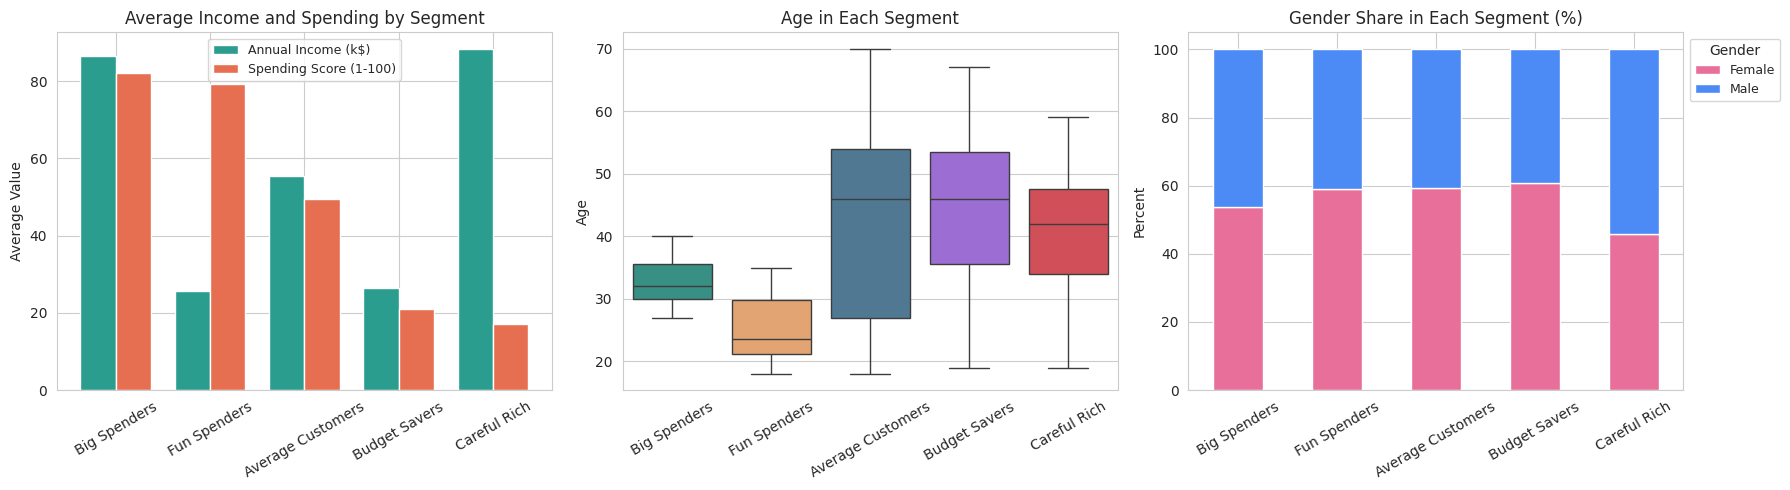

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

avg = df.groupby("Segment")[["Annual Income (k$)", "Spending Score (1-100)"]].mean().loc[order]
avg.plot(kind="bar", ax=axes[0], color=["#2a9d8f", "#e76f51"], width=0.75)
axes[0].set_title("Average Income and Spending by Segment")
axes[0].set_ylabel("Average Value")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(fontsize=9)

sns.boxplot(data=df, x="Segment", y="Age", order=order, palette=segment_colors, ax=axes[1])
axes[1].set_title("Age in Each Segment")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

gender_pct = pd.crosstab(df["Segment"], df["Gender"], normalize="index").loc[order] * 100
gender_pct.plot(kind="bar", stacked=True, ax=axes[2], color=["#e76f9a", "#4c8bf5"])
axes[2].set_title("Gender Share in Each Segment (%)")
axes[2].set_ylabel("Percent")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend(title="Gender", fontsize=9, loc="upper left", bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.show()

## Observation (Simple Words)

**Chart 1 - Average Income and Spending:**

- **Big Spenders** and **Careful Rich** have a **high income** (about 87-88k), but Big Spenders spend about **82** and Careful Rich only about **17**.
- **Fun Spenders** and **Budget Savers** both have a **low income** (about 26k), but Fun Spenders spend about **79** and Budget Savers only about **21**.
- So **income does not decide spending**. Habits matter more.

**Chart 2 - Age:**

- **Fun Spenders are the youngest** (typical age is early to mid 20s).
- **Big Spenders are also young** (early 30s).
- **Budget Savers are the oldest on average** (about 45). **Careful Rich** are about 41 on average.
- **Average Customers** have a **very wide age range** (from 18 to 70), so they are a mixed group.
- Meaning: **younger customers spend more, older customers spend less**. This matches the small negative correlation (-0.33) we saw earlier.

**Chart 3 - Gender:**

- Both **males and females** are present in every segment. The share of females stays between about **46% and 61%** in all groups.
- Gender does **not** clearly separate the groups, so the segments are made by **income and spending habits**, not by gender.

# Step 16: Business Ideas for Each Segment

| Segment | Who they are | Simple Idea for the Mall |
|---|---|---|
| **Big Spenders** | High income, high spending | Treat them as VIP. Give loyalty cards, early access to new products, and premium offers. |
| **Fun Spenders** | Young, low income, high spending | Give discounts, festival sales, and fashion or entertainment offers. They love to shop. |
| **Average Customers** | Middle income, middle spending | Largest group. Give regular offers and combo deals to **increase** their spending slowly. |
| **Careful Rich** | High income, low spending | They have money but are not spending. Find out why. Try **quality, luxury and personal offers** to attract them. |
| **Budget Savers** | Low income, low spending | Do not waste big advertising money. Give small coupons and low-price products. |

## Key Insights

- The dataset has **200 customers** and **5 columns**, with **no missing values and no duplicates**.
- **Income and Spending Score are not related** (correlation is only 0.01), so we need clustering to find hidden groups.
- The **Elbow Method** shows the bend at **K = 5**, and the **Silhouette Score** is also highest at **K = 5** (about 0.555).
- K-Means made **5 clear groups**: Average Customers (81), Big Spenders (39), Careful Rich (35), Budget Savers (23) and Fun Spenders (22).
- **Big Spenders** (high income + high spending) are the best customers to target.
- **Careful Rich** have the same income as Big Spenders but spend much less. This is a big chance to grow sales.
- **Younger customers** (Fun Spenders and Big Spenders) spend more than older customers.
- **Gender does not decide the group.** Both males and females are in all segments.

## Limitations

- We used only **two features** (Income and Spending Score). Using Age and Gender in the model may give different groups.
- The dataset is **small (200 customers)**, so results may change on a bigger dataset.
- K-Means works best with **round-shaped groups**. If groups have strange shapes, other methods (like DBSCAN) may work better.

## Conclusion

In this task we used **K-Means clustering** to divide mall customers into groups. We scaled the data, used the **Elbow Method** to find the best number of clusters (**K = 5**), confirmed it with the **Silhouette Score**, and then **visualized** the groups.

The five groups - **Average Customers, Big Spenders, Careful Rich, Fun Spenders and Budget Savers** - are clear and easy to understand. With this, the mall can plan the **right offer for the right customer** instead of one offer for everyone. This is how customer segmentation helps a business save money and earn more.